In [1]:
# 고전 컴퓨터비전 실습 — ④ 추적(Tracking) : ByteTrack
# (활용사례) 스포츠 선수 동선 분석, 매장 고객 동선 분석, 교통량·차량 속도 측정
#
# SORT/DeepSORT(실습1)는 일정 신뢰도(confidence) 이상의 탐지 박스만 사용하고,
# 그 미만(저신뢰 박스)은 "노이즈일 수 있다"며 버린다. 문제는 객체가 가려지거나
# (occlusion) 흐릿해지는 순간에는 바로 이 저신뢰 박스가 나오는데, 이걸
# 버리면 트랙이 끊긴다. ByteTrack의 핵심 아이디어는 "저신뢰 박스도 일단
# 버리지 말고, 이미 존재하는 트랙과 매칭하는 데만 써보자"는 2단계 매칭이다.
#
#   1단계: 고신뢰 탐지 ↔ 모든 트랙을 먼저 매칭 (일반적인 SORT와 동일)
#   2단계: 1단계에서 남은(매칭 안 된) 트랙들 ↔ 저신뢰 탐지를 다시 매칭
#          (여기서 매칭되면 "트랙을 살려주는" 역할만 하고, 저신뢰 탐지가
#           매칭에 실패해도 새 트랙은 만들지 않는다 — 저신뢰 박스는 노이즈일
#           가능성이 있으므로 "새로 만들기"엔 쓰지 않는다는 것이 핵심 규칙이다)
#
# 실제 ByteTrack은 YOLOX 같은 딥러닝 검출기의 출력(박스+신뢰도 점수)을 그대로
# 활용하지만, 사전학습 가중치 다운로드 없이 Colab에서 바로 실행하기 위해
# 이 실습에서는 "가려질수록 탐지 신뢰도가 낮아지는" 합성 영상 + 색상 기반
# contour 탐지기로 동일한 입력 형태(박스+신뢰도)를 재현하고, ByteTrack
# 논문이 제안하는 2단계 매칭 로직 자체를 충실히 구현해 동작을 확인한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체(Detection/Track) + 추상 인터페이스
#                        (ObjectDetector/MotionModel/Associator). 외부
#                        라이브러리에 의존하지 않는다.
#   [유스케이스 계층]   — MultiObjectTrackingUseCase. "예측→매칭→갱신→생성→
#                        소멸"이라는 추적 흐름만 조립하며, 1단계냐 2단계냐는
#                        전혀 모른다(그 차이는 Associator 구현에 캡슐화됨).
#   [인프라 계층]      — cv2 기반 탐지기(신뢰도 포함), 칼만필터, 2단계
#                        매칭기(ByteTrack) vs 단일단계 매칭기(비교용 SORT류),
#                        시각화를 구현한다.
#   [구성 루트]        — Colab 셀: 저신뢰 구간이 포함된 합성 영상 생성,
#                        DI 조립(고신뢰만 쓰는 방식 vs ByteTrack 비교), 실행.

## 셀 1: 환경 준비

In [2]:
# !pip install opencv-python-headless scipy matplotlib numpy --quiet
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
_candidates = _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf") + \
    _glob.glob("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc") + \
    _glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True)
_korean_font_name = "sans-serif"
for _font_path in _candidates:
    try:
        _font_manager.fontManager.addfont(_font_path)
        _korean_font_name = _font_manager.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue
matplotlib.rcParams["font.family"] = _korean_font_name
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====

from abc import ABC, abstractmethod
from dataclasses import dataclass, field


def compute_iou(bbox_a: tuple[float, float, float, float],
                 bbox_b: tuple[float, float, float, float]) -> float:
    """두 바운딩박스(x1,y1,x2,y2)의 IoU를 계산하는 순수 함수."""
    ax1, ay1, ax2, ay2 = bbox_a
    bx1, by1, bx2, by2 = bbox_b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter_w, inter_h = max(0.0, inter_x2 - inter_x1), max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 1e-6 else 0.0


@dataclass(frozen=True)
class Detection:
    """한 프레임의 탐지 결과 1건. confidence가 ByteTrack 2단계 매칭의
    핵심 입력이다 — 실제 서비스라면 딥러닝 검출기의 softmax 점수에 해당한다."""
    bbox: tuple[float, float, float, float]
    confidence: float


@dataclass
class Track:
    """추적 중인 객체 하나의 상태(실습1과 동일한 구조)."""
    track_id: int
    state: np.ndarray
    covariance: np.ndarray
    hits: int = 0
    age: int = 0
    time_since_update: int = 0
    history: list[tuple[float, float]] = field(default_factory=list)
    recovered_by_low_conf_count: int = 0  # ByteTrack 2단계로 "구조"된 횟수(통계용)

    @property
    def bbox(self) -> tuple[float, float, float, float]:
        cx, cy, w, h = self.state[:4]
        return (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)

    @property
    def is_confirmed(self) -> bool:
        return self.hits >= 3


class ObjectDetector(ABC):
    @abstractmethod
    def detect(self, frame: np.ndarray) -> list[Detection]:
        ...


class MotionModel(ABC):
    @abstractmethod
    def initiate(self, bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        ...

    @abstractmethod
    def predict(self, state: np.ndarray, covariance: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        ...

    @abstractmethod
    def update(self, state: np.ndarray, covariance: np.ndarray,
               bbox: tuple[float, float, float, float]) -> tuple[np.ndarray, np.ndarray]:
        ...


@dataclass(frozen=True)
class AssociationResult:
    """매칭 결과 값 객체. ByteTrack은 2단계를 거치므로, 2단계에서만 매칭된
    트랙이 몇 개였는지("구조된" 트랙 수)를 함께 돌려줄 수 있게 필드를 둔다."""
    matches: list[tuple[int, int]]
    unmatched_track_indices: list[int]
    unmatched_detection_indices: list[int]
    recovered_by_second_stage: list[int] = field(default_factory=list)  # 매칭된 track_idx 목록


class Associator(ABC):
    """"현재 트랙들과 새 탐지들을 짝짓는다"는 계약. 고신뢰만 쓰는 단일단계
    매칭기(HighConfidenceOnlyAssociator)와, 저신뢰까지 2단계로 활용하는
    ByteTrackAssociator가 이 인터페이스의 서로 다른 구현체이며 완전히
    치환 가능하다(LSP) — 유스케이스는 어느 쪽인지 모른다."""

    @abstractmethod
    def associate(self, tracks: list[Track], detections: list[Detection]) -> AssociationResult:
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====

class MultiObjectTrackingUseCase:
    """"예측 → 탐지 → 매칭 → 갱신 → 생성 → 소멸"이라는 추적 파이프라인을
    조립한다. ByteTrack의 "2단계 매칭"이라는 세부 전략은 전혀 모른 채,
    Associator가 반환한 AssociationResult만 보고 똑같이 동작한다 — 이것이
    바로 ByteTrack 논문의 아이디어를 "매칭 전략 하나의 교체"만으로 깔끔하게
    적용할 수 있게 하는 설계다(OCP)."""

    def __init__(
        self,
        detector: ObjectDetector,
        motion_model: MotionModel,
        associator: Associator,
        max_age: int = 20,
        min_new_track_confidence: float = 0.6,
    ):
        self._detector = detector
        self._motion_model = motion_model
        self._associator = associator
        self._max_age = max_age
        self._min_new_track_confidence = min_new_track_confidence
        self._tracks: list[Track] = []
        self._next_id = 1
        self.total_recoveries = 0  # 저신뢰 탐지로 트랙이 "구조"된 총 횟수(통계용)

    def process_frame(self, frame: np.ndarray) -> list[Track]:
        for track in self._tracks:
            track.state, track.covariance = self._motion_model.predict(track.state, track.covariance)
            track.age += 1
            track.time_since_update += 1

        detections = self._detector.detect(frame)
        result = self._associator.associate(self._tracks, detections)

        for track_idx, det_idx in result.matches:
            track = self._tracks[track_idx]
            det = detections[det_idx]
            track.state, track.covariance = self._motion_model.update(track.state, track.covariance, det.bbox)
            track.hits += 1
            track.time_since_update = 0
            if track_idx in result.recovered_by_second_stage:
                track.recovered_by_low_conf_count += 1
                self.total_recoveries += 1
            cx, cy = track.state[0], track.state[1]
            track.history.append((float(cx), float(cy)))

        # 새 트랙은 "신뢰도가 일정 기준 이상인 탐지"에서만 생성한다 — 저신뢰
        # 탐지는 기존 트랙을 "살리는" 데만 쓰고, 새로 트랙을 시작하는 근거로는
        # 쓰지 않는다는 ByteTrack의 규칙을 유스케이스 차원에서도 지킨다.
        for det_idx in result.unmatched_detection_indices:
            det = detections[det_idx]
            if det.confidence < self._min_new_track_confidence:
                continue
            state, covariance = self._motion_model.initiate(det.bbox)
            new_track = Track(track_id=self._next_id, state=state, covariance=covariance,
                               hits=1, time_since_update=0)
            new_track.history.append((float(state[0]), float(state[1])))
            self._tracks.append(new_track)
            self._next_id += 1

        self._tracks = [t for t in self._tracks if t.time_since_update <= self._max_age]
        return [t for t in self._tracks if t.is_confirmed or t.hits >= 1]


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2
from scipy.optimize import linear_sum_assignment


class OcclusionAwareDetector(ObjectDetector):
    """색상 기반 contour 탐지기. 다른 객체에 가려진 비율이 클수록 보이는
    면적이 줄어 confidence가 자연스럽게 낮아지도록 설계했다 — 실제 딥러닝
    검출기가 가려진 객체에 낮은 점수를 주는 현상을 재현한다.

    단, 바운딩박스는 "보이는 부분(sliver)의 윤곽"이 아니라 contour
    중심(centroid)을 기준으로 한 고정 크기 박스로 만든다. 실제 CNN
    검출기는 부분적으로 가려진 객체도 학습된 전형적인 크기로 전체 범위를
    추정해내기 때문이다(점수만 낮아질 뿐, 박스 자체가 가려진 만큼
    쪼그라들지는 않는다) — 이렇게 해야 칼만필터의 예측 박스와 비교할 때
    IoU가 "가려진 정도"가 아니라 "위치가 맞는지"만을 반영하게 된다."""

    def __init__(self, min_area: int = 25, typical_radius: float = 22.0):
        self._min_area = min_area
        self._typical_radius = typical_radius
        self._typical_full_area = np.pi * typical_radius ** 2

    def detect(self, frame: np.ndarray) -> list[Detection]:
        gray_sum = frame.sum(axis=2)
        foreground = (gray_sum > 60).astype(np.uint8)

        # 장애물에 의해 객체가 좌/우 두 조각(초승달 모양)으로 쪼개져 보일 때도,
        # 전체 전경 마스크의 모멘트(moments)를 한 번에 계산해 "조각들을 합친
        # 전체 중심"을 구한다 — 조각마다 따로 중심을 잡으면 중심이 한쪽으로
        # 치우쳐 칼만 예측 박스와의 IoU가 불필요하게 나빠지기 때문이다.
        area = float(cv2.countNonZero(foreground))
        if area < self._min_area:
            return []

        moments = cv2.moments(foreground, binaryImage=True)
        if moments["m00"] <= 1e-6:
            return []
        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]
        r = self._typical_radius
        bbox = (cx - r, cy - r, cx + r, cy + r)
        confidence = float(np.clip(area / self._typical_full_area, 0.0, 1.0))
        return [Detection(bbox=bbox, confidence=confidence)]


class ConstantVelocityKalmanMotionModel(MotionModel):
    """실습1과 동일한 등속 칼만필터(8차원 상태 [cx,cy,w,h,vx,vy,vw,vh])."""

    def __init__(self, process_noise: float = 1.0, measurement_noise: float = 1.0):
        self._dim = 8
        self._F = np.eye(self._dim)
        for i in range(4):
            self._F[i, i + 4] = 1.0
        self._H = np.zeros((4, self._dim))
        for i in range(4):
            self._H[i, i] = 1.0
        self._Q = np.eye(self._dim) * process_noise
        self._R = np.eye(4) * measurement_noise

    def initiate(self, bbox):
        x1, y1, x2, y2 = bbox
        cx, cy, w, h = (x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1
        state = np.array([cx, cy, w, h, 0, 0, 0, 0], dtype=np.float64)
        covariance = np.eye(self._dim) * 10.0
        return state, covariance

    def predict(self, state, covariance):
        state = self._F @ state
        covariance = self._F @ covariance @ self._F.T + self._Q
        return state, covariance

    def update(self, state, covariance, bbox):
        x1, y1, x2, y2 = bbox
        measurement = np.array([(x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1])
        innovation = measurement - self._H @ state
        innovation_cov = self._H @ covariance @ self._H.T + self._R
        kalman_gain = covariance @ self._H.T @ np.linalg.inv(innovation_cov)
        state = state + kalman_gain @ innovation
        covariance = (np.eye(self._dim) - kalman_gain @ self._H) @ covariance
        return state, covariance


def _iou_hungarian_match(
    tracks: list[Track], track_indices: list[int],
    detections: list[Detection], detection_indices: list[int],
    iou_threshold: float,
) -> tuple[list[tuple[int, int]], list[int], list[int]]:
    """IoU 비용 + 헝가리안 매칭의 공통 구현. "일부 트랙/탐지만" 대상으로
    매칭할 수 있도록 인덱스 부분집합을 받는다(ByteTrack 2단계에서 재사용)."""
    if not track_indices or not detection_indices:
        return [], list(track_indices), list(detection_indices)

    cost = np.ones((len(track_indices), len(detection_indices)))
    for i, t_idx in enumerate(track_indices):
        for j, d_idx in enumerate(detection_indices):
            cost[i, j] = 1.0 - compute_iou(tracks[t_idx].bbox, detections[d_idx].bbox)

    row_idx, col_idx = linear_sum_assignment(cost)
    matches = []
    matched_t, matched_d = set(), set()
    for r, c in zip(row_idx, col_idx):
        if 1.0 - cost[r, c] >= iou_threshold:
            t_idx, d_idx = track_indices[r], detection_indices[c]
            matches.append((t_idx, d_idx))
            matched_t.add(t_idx)
            matched_d.add(d_idx)

    unmatched_t = [i for i in track_indices if i not in matched_t]
    unmatched_d = [i for i in detection_indices if i not in matched_d]
    return matches, unmatched_t, unmatched_d


class HighConfidenceOnlyAssociator(Associator):
    """비교 기준(baseline) — 일정 신뢰도 미만의 탐지는 아예 버리고, 고신뢰
    탐지만으로 단일단계 IoU 매칭을 수행하는 SORT류 방식. ByteTrack이 풀고자
    하는 "저신뢰 박스를 버려서 생기는 track 손실" 문제를 그대로 겪는다."""

    def __init__(self, iou_threshold: float = 0.3, confidence_threshold: float = 0.6):
        self._iou_threshold = iou_threshold
        self._confidence_threshold = confidence_threshold

    def associate(self, tracks: list[Track], detections: list[Detection]) -> AssociationResult:
        high_conf_idx = [i for i, d in enumerate(detections) if d.confidence >= self._confidence_threshold]
        all_track_idx = list(range(len(tracks)))

        matches, unmatched_tracks, unmatched_high = _iou_hungarian_match(
            tracks, all_track_idx, detections, high_conf_idx, self._iou_threshold,
        )
        # 저신뢰 탐지는 애초에 고려 대상에서 제외했으므로 unmatched_detection에도 포함하지 않는다
        return AssociationResult(
            matches=matches,
            unmatched_track_indices=unmatched_tracks,
            unmatched_detection_indices=unmatched_high,
        )


class ByteTrackAssociator(Associator):
    """ByteTrack 방식 — 2단계 매칭.
    1단계: 고신뢰 탐지 ↔ 전체 트랙을 IoU로 매칭.
    2단계: 1단계에서 남은 트랙 ↔ 저신뢰 탐지를 더 느슨한 IoU 임계값으로
    다시 매칭한다. 2단계에서 매칭된 트랙은 "저신뢰 박스로 구조됨"으로
    기록된다. 2단계에서도 매칭되지 않은 저신뢰 탐지는 (신뢰도가 낮아
    노이즈일 수 있으므로) 그대로 버리고 새 트랙을 만들지 않는다."""

    def __init__(
        self,
        high_conf_threshold: float = 0.6,
        stage1_iou_threshold: float = 0.3,
        stage2_iou_threshold: float = 0.15,
    ):
        self._high_conf_threshold = high_conf_threshold
        self._stage1_iou_threshold = stage1_iou_threshold
        self._stage2_iou_threshold = stage2_iou_threshold

    def associate(self, tracks: list[Track], detections: list[Detection]) -> AssociationResult:
        high_idx = [i for i, d in enumerate(detections) if d.confidence >= self._high_conf_threshold]
        low_idx = [i for i, d in enumerate(detections) if d.confidence < self._high_conf_threshold]
        all_track_idx = list(range(len(tracks)))

        # 1단계: 고신뢰 탐지 ↔ 전체 트랙
        stage1_matches, unmatched_tracks, unmatched_high = _iou_hungarian_match(
            tracks, all_track_idx, detections, high_idx, self._stage1_iou_threshold,
        )

        # 2단계: 1단계에서 못 찾은 트랙 ↔ 저신뢰 탐지 (더 느슨한 임계값)
        stage2_matches, still_unmatched_tracks, unmatched_low = _iou_hungarian_match(
            tracks, unmatched_tracks, detections, low_idx, self._stage2_iou_threshold,
        )

        all_matches = stage1_matches + stage2_matches
        recovered = [t_idx for t_idx, _ in stage2_matches]

        # 새 트랙 후보는 "고신뢰인데 매칭 안 된 것"만 유스케이스에 전달한다.
        # 저신뢰 미매칭(unmatched_low)은 애초에 전달하지 않아 새 트랙 생성에
        # 쓰이지 않게 한다(ByteTrack의 핵심 규칙).
        return AssociationResult(
            matches=all_matches,
            unmatched_track_indices=still_unmatched_tracks,
            unmatched_detection_indices=unmatched_high,
            recovered_by_second_stage=recovered,
        )


class TrackingVisualizer:
    """시각화 전담 클래스(SRP)."""

    def __init__(self, title: str):
        self._title = title

    def save_trajectories(self, frame_shape: tuple[int, int],
                           track_histories: dict[int, list[tuple[float, float]]], out_path: str) -> None:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(8, 6))
        fig.suptitle(self._title, fontsize=13, fontweight="bold")
        ax.set_xlim(0, frame_shape[1])
        ax.set_ylim(frame_shape[0], 0)
        ax.set_facecolor("#111111")

        cmap = plt.get_cmap("tab10")
        for i, (track_id, pts) in enumerate(track_histories.items()):
            pts_arr = np.array(pts)
            color = cmap(i % 10)
            ax.plot(pts_arr[:, 0], pts_arr[:, 1], "-o", markersize=3, linewidth=1.8,
                     color=color, label=f"ID {track_id}")
            ax.annotate(f"{track_id}", pts_arr[0], color=color, fontsize=9, fontweight="bold")

        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
        ax.set_title(f"트랙 ID 수: {len(track_histories)}개 (적을수록 추적이 끊기지 않은 것)")
        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"저장 완료: {out_path} / 생성된 트랙 ID 총 개수: {len(track_histories)}")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 합성 "부분 가려짐(partial occlusion)" 영상 생성 — 작은 "장애물"

In [3]:
# (정적인 사각 기둥, 예: 매장의 진열대나 교통 표지판 기둥을 상징)을 화면
# 중앙에 고정해두고, 객체 하나가 그 뒤를 지나가게 한다. 장애물을 지나는
# 동안 보이는 면적이 줄어 탐지 신뢰도가 낮아지지만(저신뢰), 완전히 사라지진
# 않는다 — ByteTrack이 상정하는 전형적인 상황이다.
def generate_partial_occlusion_scene(n_frames: int = 50, width: int = 400, height: int = 300):
    frames = []
    # 장애물 폭(28px)을 객체 지름(44px)보다 좁게 만들어, 아무리 깊이
    # 가려져도 양쪽 초승달 모양 일부는 항상 보이게 한다 — ByteTrack이
    # 전제하는 "저신뢰 박스(0은 아님)" 상황을 정확히 재현하기 위함이다.
    obstacle = (int(width * 0.47), 40, int(width * 0.47) + 28, height - 40)

    for t in range(n_frames):
        frame = np.zeros((height, width, 3), dtype=np.uint8)
        progress = t / (n_frames - 1)
        x = int(40 + progress * (width - 80))
        y = height // 2

        obj_frame = np.zeros_like(frame)
        cv2.circle(obj_frame, (x, y), 22, (70, 200, 120), -1)
        # 장애물 영역은 배경(검정)으로 덮어 "가려진 부분이 안 보이게" 만든다
        ox1, oy1, ox2, oy2 = obstacle
        obj_frame[oy1:oy2, ox1:ox2] = 0
        frame = cv2.add(frame, obj_frame)
        frames.append(frame)
    return frames


frames = generate_partial_occlusion_scene(n_frames=50, width=400, height=300)
print(f"합성 프레임 수: {len(frames)}, 크기: {frames[0].shape}")
print("객체 1개가 화면 중앙의 고정 장애물(기둥) 뒤를 지나가며 신뢰도가 일시적으로 낮아짐")

MIN_NEW_TRACK_CONF = 0.6

합성 프레임 수: 50, 크기: (300, 400, 3)
객체 1개가 화면 중앙의 고정 장애물(기둥) 뒤를 지나가며 신뢰도가 일시적으로 낮아짐


## 셀 3: 비교 기준(고신뢰만 사용) 구성 — 구체 어댑터 생성 + 의존성 주입

In [4]:
baseline_tracker = MultiObjectTrackingUseCase(
    detector=OcclusionAwareDetector(min_area=25),
    motion_model=ConstantVelocityKalmanMotionModel(process_noise=1.0, measurement_noise=1.0),
    associator=HighConfidenceOnlyAssociator(iou_threshold=0.3, confidence_threshold=MIN_NEW_TRACK_CONF),
    max_age=5,  # 장애물을 지나는 프레임 수보다 짧게 설정해 "저신뢰 구간에서 실제로 끊기는지" 확인
    min_new_track_confidence=MIN_NEW_TRACK_CONF,
)

baseline_histories: dict[int, list[tuple[float, float]]] = {}
for frame in frames:
    active_tracks = baseline_tracker.process_frame(frame)
    for t in active_tracks:
        if t.history:
            baseline_histories[t.track_id] = t.history

print(f"\n[고신뢰만 사용(비교 기준)] 생성된 트랙 ID 총 개수: {len(baseline_histories)} "
      f"(물리적 객체는 1개뿐이므로, 2 이상이면 저신뢰 구간에서 추적이 끊긴 것)")


[고신뢰만 사용(비교 기준)] 생성된 트랙 ID 총 개수: 2 (물리적 객체는 1개뿐이므로, 2 이상이면 저신뢰 구간에서 추적이 끊긴 것)


## 셀 4: 비교 기준 결과 시각화

/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 47001 (\N{HANGUL SYLLABLE RAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_

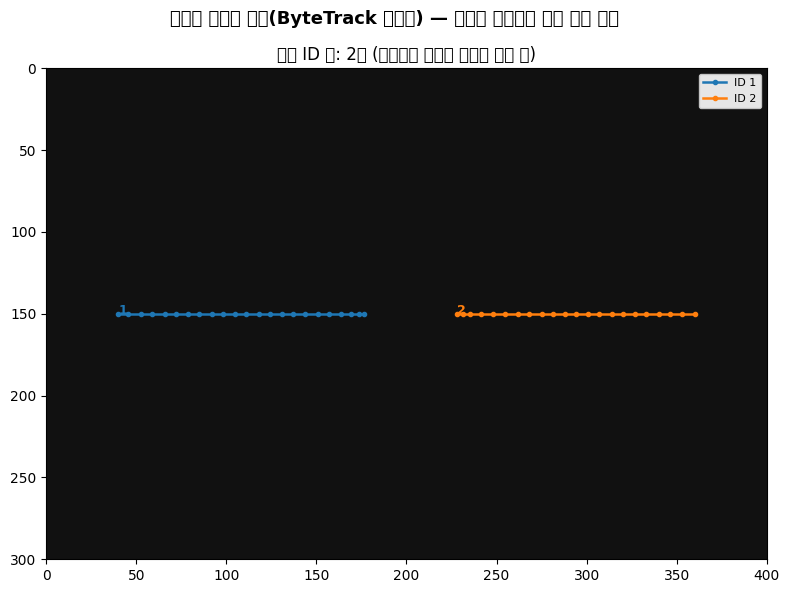

저장 완료: baseline_tracking_result.png / 생성된 트랙 ID 총 개수: 2


In [5]:
baseline_visualizer = TrackingVisualizer(
    title="고신뢰 박스만 사용(ByteTrack 미적용) — 가려짐 구간에서 추적 끊김 확인"
)
baseline_visualizer.save_trajectories(frames[0].shape[:2], baseline_histories, "baseline_tracking_result.png")

## 셀 5: ByteTrack 구성 — 같은 유스케이스 코드, Associator만 교체(OCP/LSP)

In [6]:
# HighConfidenceOnlyAssociator -> ByteTrackAssociator로 바꾸는 것 외에는
# MultiObjectTrackingUseCase를 한 줄도 수정하지 않는다.
bytetrack_tracker = MultiObjectTrackingUseCase(
    detector=OcclusionAwareDetector(min_area=25),
    motion_model=ConstantVelocityKalmanMotionModel(process_noise=1.0, measurement_noise=1.0),
    associator=ByteTrackAssociator(
        high_conf_threshold=MIN_NEW_TRACK_CONF, stage1_iou_threshold=0.3, stage2_iou_threshold=0.15,
    ),
    max_age=5,
    min_new_track_confidence=MIN_NEW_TRACK_CONF,
)

bytetrack_histories: dict[int, list[tuple[float, float]]] = {}
for frame in frames:
    active_tracks = bytetrack_tracker.process_frame(frame)
    for t in active_tracks:
        if t.history:
            bytetrack_histories[t.track_id] = t.history

print(f"\n[ByteTrack] 생성된 트랙 ID 총 개수: {len(bytetrack_histories)}")
print(f"[ByteTrack] 저신뢰 박스로 트랙이 '구조'된 횟수: {bytetrack_tracker.total_recoveries}회")


[ByteTrack] 생성된 트랙 ID 총 개수: 1
[ByteTrack] 저신뢰 박스로 트랙이 '구조'된 횟수: 5회


## 셀 6: ByteTrack 결과 시각화 및 비교

/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 47001 (\N{HANGUL SYLLABLE RAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_768/3065060818.py:390: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_

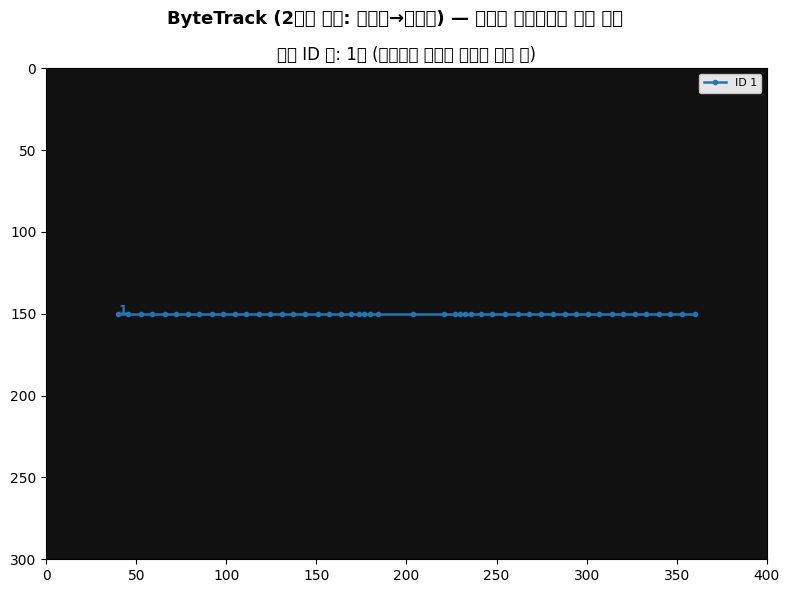

저장 완료: bytetrack_tracking_result.png / 생성된 트랙 ID 총 개수: 1

=== 고신뢰만 사용 vs ByteTrack 비교 ===
고신뢰만 사용: 트랙 ID 2개 생성
ByteTrack    : 트랙 ID 1개 생성 (저신뢰 구간에서 5회 구조)
장애물을 지나는 동안 탐지 신뢰도가 낮아지는 구간에서, 고신뢰 박스만 쓰는 방식은 그 구간의 탐지를 통째로 버려 트랙이 끊기고 새 ID가 생기는 반면, ByteTrack은 2단계에서 저신뢰 박스로 기존 트랙을 계속 갱신해 같은 ID를 유지한다.


In [7]:
bytetrack_visualizer = TrackingVisualizer(
    title="ByteTrack (2단계 매칭: 고신뢰→저신뢰) — 가려짐 구간에서도 추적 유지"
)
bytetrack_visualizer.save_trajectories(frames[0].shape[:2], bytetrack_histories, "bytetrack_tracking_result.png")

print("\n=== 고신뢰만 사용 vs ByteTrack 비교 ===")
print(f"고신뢰만 사용: 트랙 ID {len(baseline_histories)}개 생성")
print(f"ByteTrack    : 트랙 ID {len(bytetrack_histories)}개 생성 "
      f"(저신뢰 구간에서 {bytetrack_tracker.total_recoveries}회 구조)")
print("장애물을 지나는 동안 탐지 신뢰도가 낮아지는 구간에서, 고신뢰 박스만 "
      "쓰는 방식은 그 구간의 탐지를 통째로 버려 트랙이 끊기고 새 ID가 생기는 "
      "반면, ByteTrack은 2단계에서 저신뢰 박스로 기존 트랙을 계속 갱신해 "
      "같은 ID를 유지한다.")